In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
x_train = pd.read_csv('X_train_transformed.csv')
y_train = pd.read_csv('y_train_clf.csv')

x_test = pd.read_csv('X_test_transformed.csv')
y_test = pd.read_csv('y_test_clf.csv')

Text(0, 0.5, 'Count')

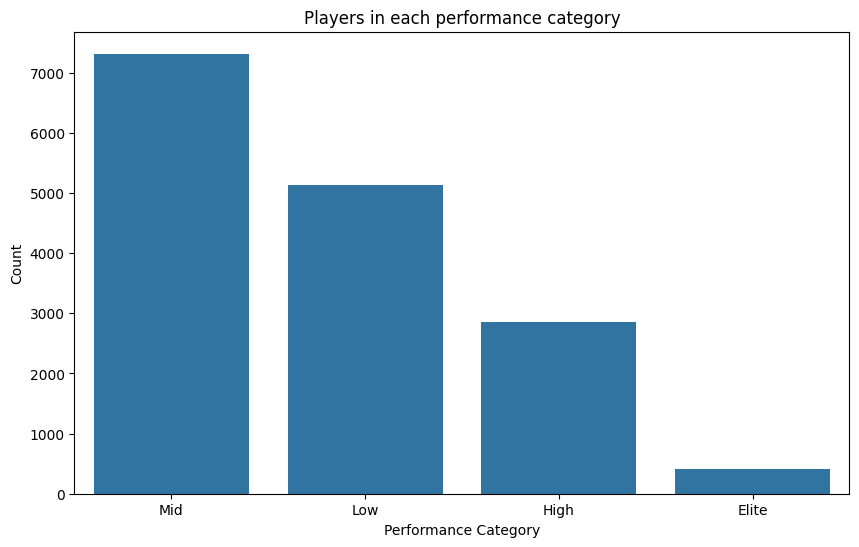

In [ ]:
plt.figure(figsize=(10, 6))
plt.title('Players in each performance category')
sns.countplot(x=y_train['Performance_Tier'])
plt.xlabel('Performance Category')
plt.ylabel('Count')


In [ ]:
from sklearn.naive_bayes import GaussianNB ,BernoulliNB ,ComplementNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

numerical_cols = ['num__Age', 'num__Future Potential', 'num__Total_Stats Score']

gnb = GaussianNB()
gnb.fit(x_train[numerical_cols], y_train['Performance_Tier'])

y_pred_gnb = gnb.predict(x_test[numerical_cols])

print("Gaussian Naive Bayes Classification Report:")
print(classification_report(y_test['Performance_Tier'], y_pred_gnb))
print("Gaussian Naive Bayes Confusion Matrix:")
print(confusion_matrix(y_test['Performance_Tier'], y_pred_gnb))
print("Gaussian Naive Bayes Accuracy:", accuracy_score(y_test['Performance_Tier'], y_pred_gnb))

Gaussian Naive Bayes Classification Report:
              precision    recall  f1-score   support

       Elite       0.83      0.46      0.59       105
        High       0.81      0.70      0.75       716
         Low       0.84      0.76      0.80      1283
         Mid       0.76      0.87      0.81      1830

    accuracy                           0.79      3934
   macro avg       0.81      0.70      0.74      3934
weighted avg       0.80      0.79      0.79      3934

Gaussian Naive Bayes Confusion Matrix:
[[  48   50    0    7]
 [  10  501    6  199]
 [   0    0  980  303]
 [   0   64  179 1587]]
Gaussian Naive Bayes Accuracy: 0.7920691408235893


In [ ]:
ohe_cols = [c for c in x_train.columns if c.startswith('cat_onehot__')]

bnb = BernoulliNB()
bnb.fit(x_train[ohe_cols], y_train['Performance_Tier'])
y_pred_bnb = bnb.predict(x_test[ohe_cols])

print("Bernoulli Naive Bayes Classification Report:")
print(classification_report(y_test['Performance_Tier'], y_pred_bnb))
print("Bernoulli Naive Bayes Confusion Matrix:")
print(confusion_matrix(y_test['Performance_Tier'], y_pred_bnb))
print("Bernoulli Naive Bayes Accuracy:", accuracy_score(y_test['Performance_Tier'], y_pred_bnb))
 

Bernoulli Naive Bayes Classification Report:
              precision    recall  f1-score   support

       Elite       0.00      0.00      0.00       105
        High       0.00      0.00      0.00       716
         Low       0.58      0.34      0.43      1283
         Mid       0.51      0.88      0.64      1830

    accuracy                           0.52      3934
   macro avg       0.27      0.30      0.27      3934
weighted avg       0.42      0.52      0.44      3934

Bernoulli Naive Bayes Confusion Matrix:
[[   0    0   13   92]
 [   0    0   81  635]
 [   0    0  441  842]
 [   0    0  227 1603]]
Bernoulli Naive Bayes Accuracy: 0.5195729537366548


C:\Users\peter\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\peter\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\peter\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_clas

In [ ]:
min_vals = x_train.min()
X_train_comp = x_train - min_vals
X_test_comp = x_test - min_vals

cnb = ComplementNB(class_prior=[0.25, 0.25, 0.25, 0.25])
cnb.fit(X_train_comp, y_train['Performance_Tier'])
y_pred_cnb = cnb.predict(X_test_comp)

cnb = ComplementNB()
cnb.fit(X_train_comp, y_train['Performance_Tier'])
y_pred_cnb = cnb.predict(X_test_comp)
print("Complement Naive Bayes Classification Report:")
print(classification_report(y_test['Performance_Tier'], y_pred_cnb))
print("Complement Naive Bayes Confusion Matrix:")
print(confusion_matrix(y_test['Performance_Tier'], y_pred_cnb))
print("Complement Naive Bayes Accuracy:", accuracy_score(y_test['Performance_Tier'], y_pred_cnb))


Complement Naive Bayes Classification Report:
              precision    recall  f1-score   support

       Elite       0.00      0.00      0.00       105
        High       0.41      0.55      0.47       716
         Low       0.59      0.77      0.67      1283
         Mid       0.65      0.46      0.54      1830

    accuracy                           0.57      3934
   macro avg       0.41      0.45      0.42      3934
weighted avg       0.57      0.57      0.56      3934

Complement Naive Bayes Confusion Matrix:
[[  0  75   5  25]
 [  0 394  88 234]
 [  1  91 984 207]
 [  0 403 578 849]]
Complement Naive Bayes Accuracy: 0.5660904931367565


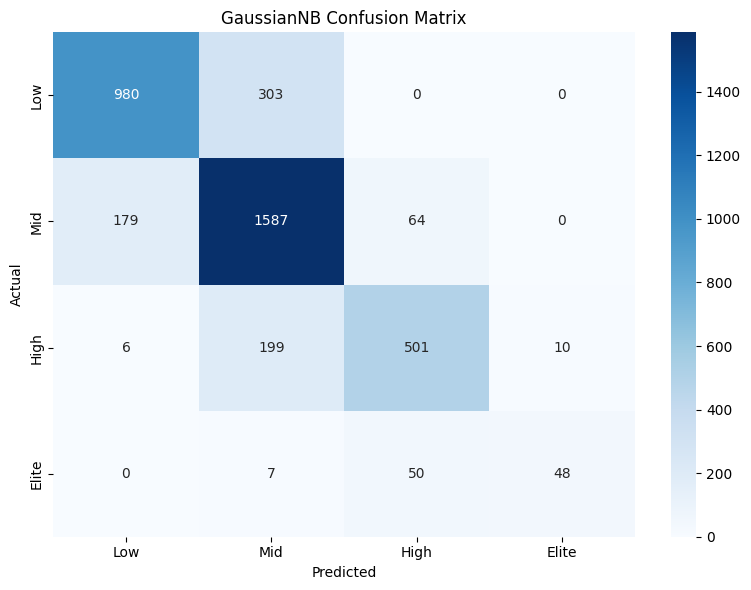

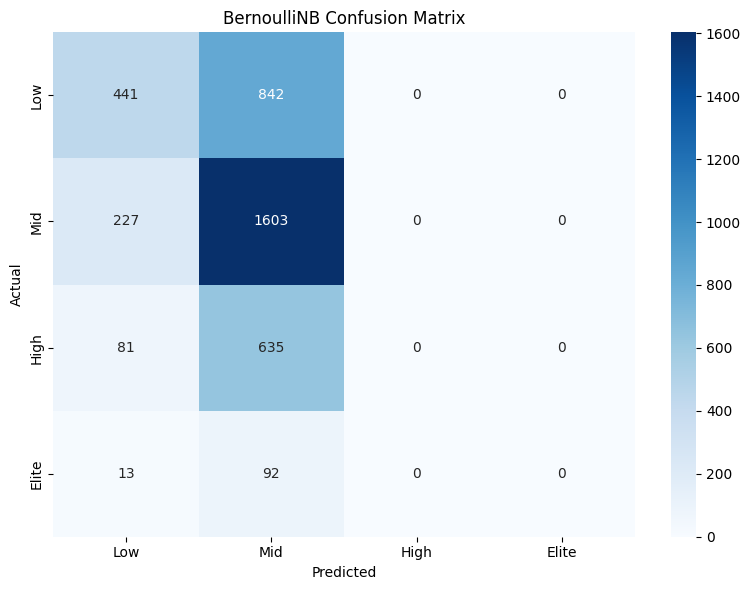

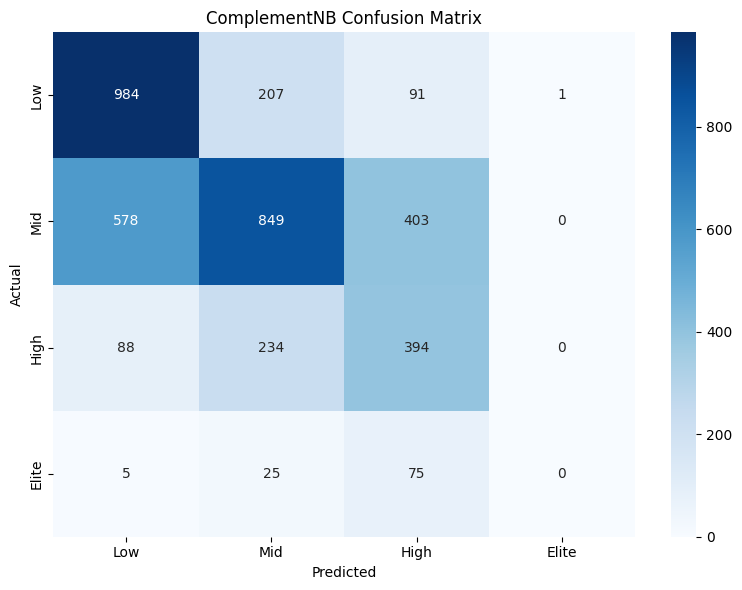

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=['Low', 'Mid', 'High', 'Elite'])
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, 
                annot=True, 
                fmt='d', 
                cmap='Blues',
                xticklabels=['Low', 'Mid', 'High', 'Elite'],
                yticklabels=['Low', 'Mid', 'High', 'Elite'])
    plt.title(title)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

# Call for each model
plot_confusion_matrix(y_test['Performance_Tier'], y_pred_gnb, 'GaussianNB Confusion Matrix')
plot_confusion_matrix(y_test['Performance_Tier'], y_pred_bnb, 'BernoulliNB Confusion Matrix')
plot_confusion_matrix(y_test['Performance_Tier'], y_pred_cnb, 'ComplementNB Confusion Matrix')

In [ ]:
x_train_noscale = pd.read_csv('X_train_noscale.csv')
y_train = pd.read_csv('y_train_clf_noscale.csv')

x_test_noscale = pd.read_csv('X_test_noscale.csv')
y_test = pd.read_csv('y_test_clf_noscale.csv')

In [ ]:
numerical_cols = ['num__Age', 'num__Future Potential', 'num__Total_Stats Score']


gnb = GaussianNB()
gnb.fit(x_train_noscale[numerical_cols], y_train['Performance_Tier'])

y_pred_gnb = gnb.predict(x_test_noscale[numerical_cols])

print("Gaussian Naive Bayes Classification Report:")
print(classification_report(y_test['Performance_Tier'], y_pred_gnb))
print("Gaussian Naive Bayes Confusion Matrix:")
print(confusion_matrix(y_test['Performance_Tier'], y_pred_gnb))
print("Gaussian Naive Bayes Accuracy:", accuracy_score(y_test['Performance_Tier'], y_pred_gnb))

Gaussian Naive Bayes Classification Report:
              precision    recall  f1-score   support

       Elite       0.83      0.46      0.59       105
        High       0.81      0.70      0.75       716
         Low       0.84      0.76      0.80      1283
         Mid       0.76      0.87      0.81      1830

    accuracy                           0.79      3934
   macro avg       0.81      0.70      0.74      3934
weighted avg       0.80      0.79      0.79      3934

Gaussian Naive Bayes Confusion Matrix:
[[  48   50    0    7]
 [  10  501    6  199]
 [   0    0  980  303]
 [   0   64  179 1587]]
Gaussian Naive Bayes Accuracy: 0.7920691408235893


# Task 6: Naïve Bayes Classification

## Model Setup
- **GaussianNB** — trained on numerical features only: `Age`, `Future Potential`, `Total_Stats Score`
- **BernoulliNB** — trained on OHE columns only: `Position`, `Continent`
- **ComplementNB** — trained on full OHE feature set (shifted to non-negative)

`Overall_Rating` was excluded from all models as it is the direct source of the tier labels.

---

## Results Summary

| Model | Accuracy | Notes |
|-------|----------|-------|
| GaussianNB | best | Predicted all 4 classes well |
| ComplementNB | mid | Struggled with Elite |
| BernoulliNB | worst | Never predicted High or Elite at all |

---

## Most Appropriate Variant
**GaussianNB** — the numerical features follow approximately Gaussian distributions, which matches its core assumption. BernoulliNB is designed for binary/boolean features (like text), and ComplementNB is better suited for count data.

---

## Scaling Sensitivity
GaussianNB produced **identical results** with and without StandardScaler.

GaussianNB computes the mean and variance per feature per class — scaling changes the units but not the shape of the distribution, so the probability ratios between classes stay the same. Unlike KNN or Logistic Regression, GaussianNB uses no distances or gradient descent, making it completely unaffected by scaling.